## Data cleaning process and Transformation of datatype 

##### What we do here ?
1. Reload the data
2. Fix missing values
3. Remove outliers
4. Fix data types
5. Clean inconsistent categories
6. Engineer new features
7. Drop useless columns
8. Save the clean dataset

In [2]:
#importing libraries  
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

In [4]:
#load raw data 
data = pd.read_csv("../data/marketing_campaign.csv", sep=";")

#working on a copy file keeping raw data safe
data_clean = data.copy()
data_clean.head(5)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,0,0,0,0,0,0,3,11,0


##### we will be working on a copy of th original dataset because we will not be overwriting the raw data file in larget set for safety 

In [8]:
## Checking the missing values and if there is missing value we correct it 
data_clean.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

Income has 23 missing values 

In [9]:
data_clean['Income'].isnull().sum()

np.int64(24)

In [ ]:
#Removing the missing value inside the Income column

data_clean = data_clean.dropna(subset=['Income']) #using dropna we remove the missing values - subset ensures only rows with missign 
data_clean['Income'].isna().sum()

np.int64(0)

#### we are removing the missing values inside the Income because we cannot determine the persons income

### Checking the Outliers and Removing it

In [12]:
data.dtypes

ID                       int64
Year_Birth               int64
Education               object
Marital_Status          object
Income                 float64
Kidhome                  int64
Teenhome                 int64
Dt_Customer             object
Recency                  int64
MntWines                 int64
MntFruits                int64
MntMeatProducts          int64
MntFishProducts          int64
MntSweetProducts         int64
MntGoldProds             int64
NumDealsPurchases        int64
NumWebPurchases          int64
NumCatalogPurchases      int64
NumStorePurchases        int64
NumWebVisitsMonth        int64
AcceptedCmp3             int64
AcceptedCmp4             int64
AcceptedCmp5             int64
AcceptedCmp1             int64
AcceptedCmp2             int64
Complain                 int64
Z_CostContact            int64
Z_Revenue                int64
Response                 int64
dtype: object

In [13]:
#Checking the outliers in numerical columns 
num_cols = data_clean.select_dtypes(include=['int64','float64']).columns

outlier_summary = []
for col in num_cols:
     Q1 = data_clean[col].quantile(0.25)
     Q3 = data_clean[col].quantile(0.75)
     IQR = Q3 - Q1

     lower = Q1 - 1.5 * IQR
     upper = Q3 + 1.5 * IQR

     count = ((data_clean[col] < lower) | (data_clean[col] > upper)).sum()

     outlier_summary.append({
          'column': col,
          'outlier_count': count,
          'percentage': round((count / len(data_clean)) * 100, 2)
     })

In [15]:
#Converting into dataframe and sort
outlier_data = pd.DataFrame(outlier_summary)
outlier_data = outlier_data.sort_values(by='percentage', ascending=False)

print(outlier_data)

                 column  outlier_count  percentage
25             Response            333       15.03
7             MntFruits            246       11.10
10     MntSweetProducts            246       11.10
9       MntFishProducts            222       10.02
11         MntGoldProds            205        9.25
8       MntMeatProducts            174        7.85
18         AcceptedCmp4            164        7.40
17         AcceptedCmp3            163        7.36
19         AcceptedCmp5            162        7.31
20         AcceptedCmp1            142        6.41
12    NumDealsPurchases             84        3.79
6              MntWines             35        1.58
21         AcceptedCmp2             30        1.35
14  NumCatalogPurchases             23        1.04
22             Complain             21        0.95
2                Income              8        0.36
16    NumWebVisitsMonth              8        0.36
1            Year_Birth              3        0.14
13      NumWebPurchases        

In [16]:
# Let's focus on only problematic columns 

high_outlier = outlier_data[outlier_data['percentage']>5]
high_outlier

,column,outlier_count,percentage
25,Response,333,15.03
7,MntFruits,246,11.10
10,MntSweetProducts,246,11.10
9,MntFishProducts,222,10.02
11,MntGoldProds,205,9.25
8,MntMeatProducts,174,7.85
18,AcceptedCmp4,164,7.40
17,AcceptedCmp3,163,7.36
19,AcceptedCmp5,162,7.31
20,AcceptedCmp1,142,6.41


the following column will be not working for now let's check the column of yeear_birth and Income 

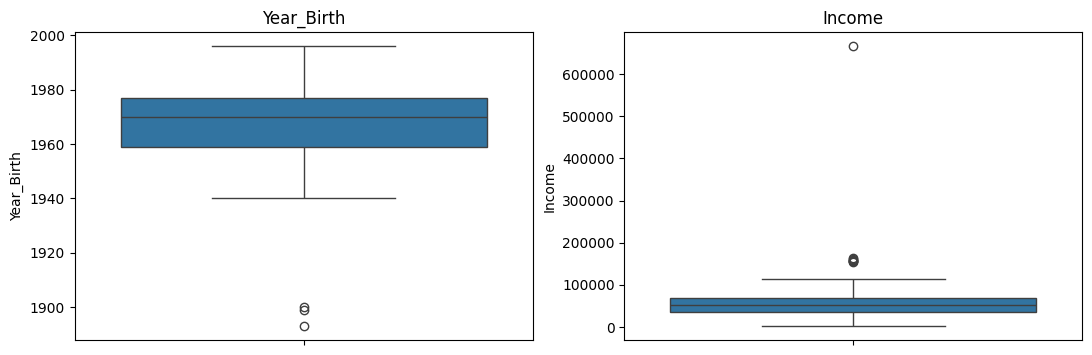

In [21]:
# Checking visualizaiton with 2 columns 
plt.figure(figsize=(13,4))

plt.subplot(1,2,1)
sns.boxplot(y=data_clean['Year_Birth'])
plt.title('Year_Birth')

plt.subplot(1,2,2)
sns.boxplot(y=data_clean['Income'])
plt.title('Income')

plt.show() 